# 04 — Mô hình truy xuất tài liệu

**Yêu cầu 3 của đồ án.**

Câu hỏi của notebook này: trong các mô hình truy xuất kinh điển, mô hình nào
phù hợp với bộ dữ liệu RETECO Track 1a?

Notebook **không** chọn trước một mô hình rồi đi tìm lý do biện minh :((. Cả năm
mô hình được đo trên cùng dữ liệu, cùng cách tách từ, cùng cách chấm điểm. Mô
hình nào thắng thì thắng (yay).

### Vì sao phải đo chứ không suy ra từ sách

Notebook `03a` đã cho một bài học cụ thể: ba giả thuyết nghe rất hợp lý đều bị
số liệu bác bỏ, trong đó có một trường hợp **đảo dấu** — cùng một thay đổi, với
bộ tách từ này thì tốt lên, với bộ tách từ khác thì xấu đi.

Nên ở đây mỗi mô hình được chạy với **hai bộ tách từ** khác nhau. Nếu thứ tự
xếp hạng giữa các mô hình giữ nguyên ở cả hai, kết luận vững. Nếu đổi, phải nói
rõ là kết luận phụ thuộc bộ tách từ.

### Đầu ra

| Tệp | Nội dung |
| --- | --- |
| `results/retrieval_models.json` | Điểm từng câu hỏi của 5 mô hình × 2 bộ tách từ |
| `results/retrieval_models_summary.json` | Bảng tổng hợp |

---

## 1. Năm cách chấm điểm một tài liệu

Mọi mô hình ở đây đều làm đúng hai việc:

1. **Đếm** mỗi từ xuất hiện bao nhiêu lần trong mỗi tài liệu → gọi là *chỉ mục*
2. **Biến số đếm thành trọng số**, rồi cộng trọng số của các từ trong câu hỏi →
   gọi là *mô hình*

Việc 1 giống nhau ở cả năm mô hình và là việc tốn thời gian nhất. Việc 2 chỉ là
một phép biến đổi trên dãy số đã đếm, rất nhanh.

Vì vậy code chỉ đọc kho văn bản **một lần**, rồi đổi qua đổi lại giữa năm cách
tính trọng số. Đó là điều làm cho việc so 5 mô hình trên 13 nhóm trở nên khả
thi.

### Bảng so sánh

| Mô hình | Trọng số của một từ trong một tài liệu | Ý tưởng |
| --- | --- | --- |
| `boolean_and` | 1 nếu có, và **phải có đủ mọi từ** | Lọc, không xếp hạng |
| `boolean_or` | 1 nếu có | Đếm số từ khớp |
| `tf` | `1 + log(f)` | Từ nào lặp nhiều thì quan trọng |
| `tfidf` | `(1 + log(f)) × log(N/df)`, rồi chuẩn hoá độ dài | Từ hiếm thì quan trọng hơn |
| `bm25` | công thức Okapi, có `k1` và `b` | Như `tfidf` nhưng lặp nhiều bị chặn lại |

Trong đó `f` = số lần từ xuất hiện trong tài liệu, `df` = số tài liệu có chứa từ
đó, `N` = tổng số tài liệu.

### Bốn ý tưởng, theo thứ tự tăng dần độ tinh vi

**Boolean** — chỉ quan tâm *có* hay *không có*. Đây là mô hình cổ nhất và là
cách các hệ thống tra cứu thư viện thời đầu hoạt động.

- `boolean_and` trả về một **tập hợp**, không phải một danh sách xếp hạng. Các
  tài liệu qualified đều bình đẳng, mô hình không có lý do gì để thích cái này
  hơn cái kia. Code trả về chúng theo thứ tự mã tài liệu, và nói rõ rằng thứ tự
  đó là tuỳ ý.
- `boolean_or` có xếp hạng, nhưng rất thô: điểm là số nguyên nhỏ (khớp 1 từ, 2
  từ, 3 từ…), nên **rất nhiều tài liệu bằng điểm nhau**.

**tf** — thêm một ý: từ nào lặp lại nhiều lần trong tài liệu thì tài liệu đó
nói về từ đó nhiều hơn. Dùng `log` để lần thứ 10 không quan trọng gấp 10 lần
thứ nhất.

Nhược điểm lớn: từ `the` xuất hiện trong mọi tài liệu mà vẫn được tính điểm như
một từ hiếm.

**tfidf** — sửa đúng nhược điểm đó bằng hai thứ:

- `log(N/df)`: từ càng ít tài liệu chứa thì càng đáng giá. Từ có mặt ở mọi tài
  liệu thì `df = N` nên trọng số bằng 0, tự động biến mất.
- **chuẩn hoá độ dài**: chia vectơ của mỗi tài liệu cho độ dài của nó. Không có
  bước này thì tài liệu dài luôn thắng, chỉ vì nó có nhiều từ để cộng hơn.

**bm25** — thêm hai chỗ tinh chỉnh so với `tfidf`:

- Số lần lặp **bão hoà**: tham số `k1` quyết định lặp bao nhiêu lần thì thôi
  không cộng thêm nữa.
- Cách trừng phạt độ dài **điều chỉnh được**: tham số `b` từ 0 (không quan tâm
  độ dài) tới 1 (trừng phạt hoàn toàn).

Hai tham số này là nội dung của notebook `05`.

### Một lưu ý về `idf`

`tfidf` dùng `log(N/df)`, `bm25` dùng `log(1 + (N − df + 0,5)/(df + 0,5))`.
Hai công thức khác nhau. Code **không** trộn chúng lại: mục đích là so các mô
hình đúng như chúng được định nghĩa, không phải so một bản pha trộn.

---

## 2. Nạp thư viện và cấu hình

Cấu hình câu hỏi (`title_weighted`) và bộ tách từ chính (`nohtml_stop`) là kết
quả đã chốt ở notebook `03a`. Notebook này giữ nguyên hai thứ đó và **chỉ đổi
mô hình**, đúng nguyên tắc mỗi lần một thay đổi.

In [1]:
import sys
import json
import time
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
import reteco as R

DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
CACHE = Path("results")
CACHE.mkdir(exist_ok=True)

assert DATA.is_dir(), f"Dataset not found at {DATA}"

# This notebook needs code added to reteco.py after notebook 03b. Fail here
# with a clear message rather than deep inside the run loop.
for required in ("RetrievalIndex", "make_split", "restrict"):
    assert hasattr(R, required), (
        f"src/reteco.py is missing {required}. Replace it with the current "
        f"version and restart the kernel.")

domains = R.list_domains(DATA)

# --- the configuration chosen in notebook 03a ---------------------------
HTML_TAG = re.compile(r"<[^>]+>")
HTML_ENTITY = re.compile(r"&(?:quot|amp|lt|gt|nbsp|apos|#\d+);")


def strip_markup(text):
    text = HTML_ENTITY.sub(" ", HTML_TAG.sub(" ", text))
    return re.sub(r"\s+", " ", text).strip()


def title_of(text):
    match = re.search(r"<p>", text)
    return text[:match.start()] if match else text


def query_form(text):
    """title_weighted: the title three times, then the whole post."""
    return strip_markup((title_of(text) + " ") * 3 + text)


# --- what is being compared -------------------------------------------
MODELS = ["boolean_and", "boolean_or", "tf", "tfidf", "bm25"]

# Two tokenisers, to catch a conclusion that only holds for one of them.
# nohtml_stop is the chosen configuration; simple is the starter kit's.
TOKENIZERS = {
    "nohtml_stop": R.make_tokenizer(drop_html=True,
                                    stopwords=R.EXTENDED_STOPWORDS),
    "simple": R.tokenize_simple,
}

TOP_K = 100

print(f"{len(domains)} domains")
print(f"{len(MODELS)} models x {len(TOKENIZERS)} tokenisers = "
      f"{len(MODELS) * len(TOKENIZERS)} configurations")

13 domains
5 models x 2 tokenisers = 10 configurations


In [2]:
# --- Shared chart style -------------------------------------------------
# One palette and one set of helpers for every figure, so the notebook reads
# as a single document rather than a pile of unrelated plots.
# Palette is colour-vision-deficiency safe; values are always labelled so the
# chart never relies on colour alone.
BLUE, ORANGE, TEAL, AMBER, PINK, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")
SURFACE, INK, INK_SOFT, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT,
    "axes.labelsize": 9.5,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "font.size": 10,
    "figure.dpi": 120,
    "axes.linewidth": 0.9,
})


def finish(ax, title, subtitle=None, xlabel=None, ylabel=None,
           grid_axis="y", note=None):
    """Apply the shared layout: title block, recessive grid, minimal frame.

    The title carries the claim; the subtitle carries the qualifier. Keeping
    them apart stops titles from turning into sentences.
    """
    if subtitle:
        ax.set_title(subtitle, loc="left", pad=8, fontsize=9.5, color=INK_MUTED)
        ax.annotate(title, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 24), textcoords="offset points",
                    ha="left", va="bottom", fontsize=12.5,
                    fontweight="bold", color=INK, annotation_clip=False)
    else:
        ax.set_title(title, loc="left", pad=12, fontsize=12.5,
                     fontweight="bold", color=INK)

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left" if grid_axis == "x" else "bottom"].set_color(AXIS)
    if grid_axis == "x":
        ax.spines["bottom"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)

    if note:
        ax.text(0, -0.34, note, transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=INK_MUTED)
    return ax


def label_bars(ax, bars, values, fmt="{:,.0f}", horizontal=True, pad=0.015):
    """Direct value labels. Always present, so colour never carries the number."""
    span = max(values) if values else 1
    for bar, value in zip(bars, values):
        if horizontal:
            ax.text(bar.get_width() + span * pad,
                    bar.get_y() + bar.get_height() / 2,
                    fmt.format(value), va="center", ha="left",
                    fontsize=8.5, color=INK_SOFT)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + span * pad,
                    fmt.format(value), ha="center", va="bottom",
                    fontsize=8.5, color=INK_SOFT)


def legend_below(ax, ncol=2, y=-0.30):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, y),
              ncol=ncol, fontsize=9.5, handlelength=1.1, handleheight=1.1,
              columnspacing=1.8)

---

## 3. Cổng kiểm tra: đường BM25 vẫn phải khớp bản tham chiếu

Để so được năm mô hình bằng một chỉ mục dùng chung, code trong `reteco.py` đã
được viết lại: lớp `BM25` cũ giờ là một trường hợp riêng của lớp tổng quát
`RetrievalIndex`.

Viết lại code đang chạy đúng là việc có rủi ro. Nên **trước khi dùng nó để kết
luận bất cứ điều gì**, ô dưới đây kiểm tra lại từ đầu:

| # | Kiểm tra gì | Vì sao |
| --- | --- | --- |
| 1 | `BM25` vẫn cho kết quả giống hệt bản tham chiếu của ban tổ chức | Đây là điều kiện để mọi số ở notebook `02`, `03a`, `03b` còn giá trị |
| 2 | `RetrievalIndex(weighting="bm25")` giống hệt `BM25` | Hai đường code phải cùng một kết quả |
| 3 | Đổi qua cả năm mô hình rồi quay về `bm25` thì kết quả không đổi | Chứng tỏ việc đổi mô hình không làm hỏng chỉ mục |
| 4 | `boolean_and` luôn là tập con của `boolean_or` | Đúng theo định nghĩa: AND chặt hơn OR |
| 5 | Vectơ `tfidf` của mỗi tài liệu có độ dài bằng 1 | Điều kiện để phép đo là cosine |

Nếu bất kỳ dòng nào không phải `PASS` thì **dừng lại**, đừng đọc tiếp các số
phía dưới.

In [3]:
# A small synthetic corpus with deliberate duplicates: duplicates score
# identically, and equal scores are exactly where a reimplementation goes
# wrong without anyone noticing.
import random

random.seed(7)
WORDS = "alpha beta gamma delta epsilon zeta eta theta iota kappa the of and a to".split()
gate_docs = [" ".join(random.choice(WORDS) for _ in range(random.randint(5, 60)))
             for _ in range(400)]
gate_docs += [gate_docs[3]] * 25                       # 25 exact duplicates
gate_ids = [f"d{i:04d}" for i in range(len(gate_docs))]
random.shuffle(gate_ids)                               # ids must not follow order
gate_queries = [" ".join(random.sample(WORDS, random.randint(1, 4)))
                for _ in range(12)]

results_gate = []

# 1 -- the BM25 name still matches the starter kit's reference implementation
same = sum(
    [d for d, _ in R.BM25(gate_ids, gate_docs).search(q, 50)]
    == [d for d, _ in R.reference_bm25_search(gate_ids, gate_docs, q, 50)]
    for q in gate_queries)
results_gate.append(("BM25 == reference implementation",
                     same == len(gate_queries), f"{same}/{len(gate_queries)}"))

# 2 -- the general class, set to bm25, matches the specialised one
general = R.RetrievalIndex(gate_ids, gate_docs, weighting="bm25")
same = sum(general.search(q, 50) == R.BM25(gate_ids, gate_docs).search(q, 50)
           for q in gate_queries)
results_gate.append(("RetrievalIndex(bm25) == BM25",
                     same == len(gate_queries), f"{same}/{len(gate_queries)}"))

# 3 -- cycling through every weighting leaves bm25 unchanged
before = [general.search(q, 20) for q in gate_queries]
for weighting in R.RetrievalIndex.WEIGHTINGS:
    general.set_weighting(weighting)
general.set_weighting("bm25")
after = [general.search(q, 20) for q in gate_queries]
results_gate.append(("bm25 stable after switching weightings",
                     before == after, "identical" if before == after else "CHANGED"))

# 4 -- AND is a subset of OR, by definition
general.set_weighting("boolean_or")
or_hits = {d for d, _ in general.search("alpha beta gamma", top_k=10_000)}
general.set_weighting("boolean_and")
and_hits = {d for d, _ in general.search("alpha beta gamma", top_k=10_000)}
results_gate.append(("boolean_and subset of boolean_or", and_hits <= or_hits,
                     f"{len(and_hits)} of {len(or_hits)}"))

# 5 -- tfidf document vectors are unit length, so the score is a cosine
general.set_weighting("tfidf")
norms = np.sqrt(np.asarray(general.index.multiply(general.index).sum(axis=0)).ravel())
deviation = float(np.abs(norms[norms > 0] - 1).max())
results_gate.append(("tfidf vectors unit length", deviation < 1e-9,
                     f"max deviation {deviation:.1e}"))

print(f"{'check':<44}{'verdict':<8}{'detail'}")
print("-" * 76)
for name, passed, detail in results_gate:
    print(f"{name:<44}{'PASS' if passed else 'FAIL':<8}{detail}")
print("-" * 76)
assert all(passed for _, passed, _ in results_gate), "a gate failed; stop here"
print("All gates passed. The numbers below can be trusted.")

del general, gate_docs, gate_ids

check                                       verdict detail
----------------------------------------------------------------------------
BM25 == reference implementation            PASS    12/12
RetrievalIndex(bm25) == BM25                PASS    12/12
bm25 stable after switching weightings      PASS    identical
boolean_and subset of boolean_or            PASS    223 of 425
tfidf vectors unit length                   PASS    max deviation 2.4e-13
----------------------------------------------------------------------------
All gates passed. The numbers below can be trusted.


---

## 4. Chạy 13 nhóm × 2 bộ tách từ × 5 mô hình

Mỗi nhóm được đọc và tách từ **một lần cho mỗi bộ tách từ**, rồi năm mô hình
dùng chung chỉ mục đó. Nếu làm ngây thơ — dựng lại chỉ mục cho từng mô hình —
thời gian sẽ gấp khoảng năm lần.

Thời gian dự kiến: **khoảng 25–35 phút**.

Kết quả được lưu ra tệp. Chạy lại ô này lần sau sẽ đọc từ tệp thay vì tính lại.
Muốn tính lại thật thì xoá `results/retrieval_models.json`.

> **Lưu ý về `n_topics`.** Ô này ghi lại số câu hỏi *thực sự được chấm* cho từng
> mô hình. Con số đó không phải thông tin phụ: bộ chấm chính thức **loại** câu
> hỏi không có kết quả ra khỏi trung bình chứ không cho 0 điểm. Mục 7 sẽ cho
> thấy hậu quả.

In [4]:
run_file = CACHE / "retrieval_models.json"

if run_file.exists():
    raw = json.loads(run_file.read_text(encoding="utf-8"))
    scored = {key: value for key, value in raw.items()}
    print("Loaded from cache. Delete results/retrieval_models.json to rerun.")
else:
    scored = {f"{t}|{m}": {} for t in TOKENIZERS for m in MODELS}
    started = time.time()

    for tokenizer_name, tokenizer in TOKENIZERS.items():
        print(f"\n=== tokenizer: {tokenizer_name} ===", flush=True)
        for i, domain in enumerate(domains, start=1):
            t0 = time.time()
            doc_ids, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")
            queries = R.load_queries(DATA / domain / "examples_train.jsonl")
            gold = R.load_qrels(DATA / domain / "qrels_train.txt")
            forms = [(qid, query_form(text)) for qid, text in queries]

            # Built once with the first weighting; set_weighting then swaps the
            # weights without re-reading the corpus.
            index = R.RetrievalIndex(doc_ids, doc_texts, tokenizer=tokenizer,
                                     weighting=MODELS[0])
            for model in MODELS:
                index.set_weighting(model)
                run = {qid: [d for d, _ in index.search(form, top_k=TOP_K)]
                       for qid, form in forms}
                scored[f"{tokenizer_name}|{model}"][domain] = R.evaluate(run, gold)

            del index, doc_ids, doc_texts
            print(f"  [{i:>2}/{len(domains)}] {domain:<12}"
                  f"{time.time() - t0:>6.0f}s", flush=True)

    run_file.write_text(json.dumps(scored), encoding="utf-8")
    print(f"\nTotal: {(time.time() - started) / 60:.1f} min")

# Sanity: the bm25 + nohtml_stop cell must reproduce notebook 03a's number
reference_value = R.macro(scored["nohtml_stop|bm25"])
print(f"\nmacro nDCG@10 for nohtml_stop + bm25 = {reference_value:.4f}"
      f"   (notebook 03a reported 0.1463)")
assert abs(reference_value - 0.1463) < 0.0005, (
    "this configuration no longer reproduces notebook 03a; something changed")


=== tokenizer: nohtml_stop ===
  [ 1/13] bitcoin         67s
  [ 2/13] cardano         41s
  [ 3/13] economics       35s
  [ 4/13] genealogy       77s
  [ 5/13] history        450s
  [ 6/13] hsm            159s
  [ 7/13] iota            12s
  [ 8/13] law             26s
  [ 9/13] monero          67s
  [10/13] politics       127s
  [11/13] quant           16s
  [12/13] travel          96s
  [13/13] workplace       29s

=== tokenizer: simple ===
  [ 1/13] bitcoin        108s
  [ 2/13] cardano         63s
  [ 3/13] economics       60s
  [ 4/13] genealogy      124s
  [ 5/13] history        510s
  [ 6/13] hsm            179s
  [ 7/13] iota            12s
  [ 8/13] law             27s
  [ 9/13] monero          70s
  [10/13] politics       152s
  [11/13] quant           21s
  [12/13] travel         134s
  [13/13] workplace       41s

Total: 45.0 min

macro nDCG@10 for nohtml_stop + bm25 = 0.1463   (notebook 03a reported 0.1463)


---

## 5. Bảng kết quả

Ba cột cho mỗi bộ tách từ:

| Cột | Nghĩa |
| --- | --- |
| `nDCG@10` | Điểm chính thức: đáp án có được xếp lên đầu không |
| `recall@100` | Trong 100 kết quả đầu, bắt được bao nhiêu phần đáp án |
| `topics` | Số câu hỏi được chấm, trên tổng 1.211 |

In [5]:
summary = {}
for key, per_domain in scored.items():
    summary[key] = {
        "ndcg": R.macro(per_domain, "ndcg"),
        "recall": R.macro(per_domain, "recall"),
        "n_topics": sum(d["n_topics"] for d in per_domain.values()),
        "n_gold": sum(d["n_gold_queries"] for d in per_domain.values()),
    }

total_queries = summary["nohtml_stop|bm25"]["n_gold"]

header = f"{'model':<14}"
for tokenizer_name in TOKENIZERS:
    header += f"{tokenizer_name:>30}"
print(header)
print(" " * 14 + ("".join(f"{'nDCG@10':>11}{'recall@100':>12}{'topics':>7}"
                          for _ in TOKENIZERS)))
print("-" * (14 + 30 * len(TOKENIZERS)))
for model in MODELS:
    line = f"{model:<14}"
    for tokenizer_name in TOKENIZERS:
        s = summary[f"{tokenizer_name}|{model}"]
        line += f"{s['ndcg']:>11.4f}{s['recall']:>12.4f}{s['n_topics']:>7}"
    print(line)
print("-" * (14 + 30 * len(TOKENIZERS)))
print(f"{'(queries)':<14}" + "".join(f"{'':>23}{total_queries:>7}"
                                     for _ in TOKENIZERS))

best = max(summary, key=lambda k: summary[k]["ndcg"])
print(f"\nHighest nDCG@10: {best}  =  {summary[best]['ndcg']:.4f}")

model                            nohtml_stop                        simple
                  nDCG@10  recall@100 topics    nDCG@10  recall@100 topics
--------------------------------------------------------------------------
boolean_and        0.0011      0.0008   1211     0.0011      0.0008   1211
boolean_or         0.0014      0.0103   1211     0.0014      0.0045   1211
tf                 0.0021      0.0197   1211     0.0000      0.0024   1211
tfidf              0.1407      0.5084   1211     0.1452      0.5015   1211
bm25               0.1463      0.4075   1211     0.1139      0.3078   1211
--------------------------------------------------------------------------
(queries)                               1211                          1211

Highest nDCG@10: nohtml_stop|bm25  =  0.1463


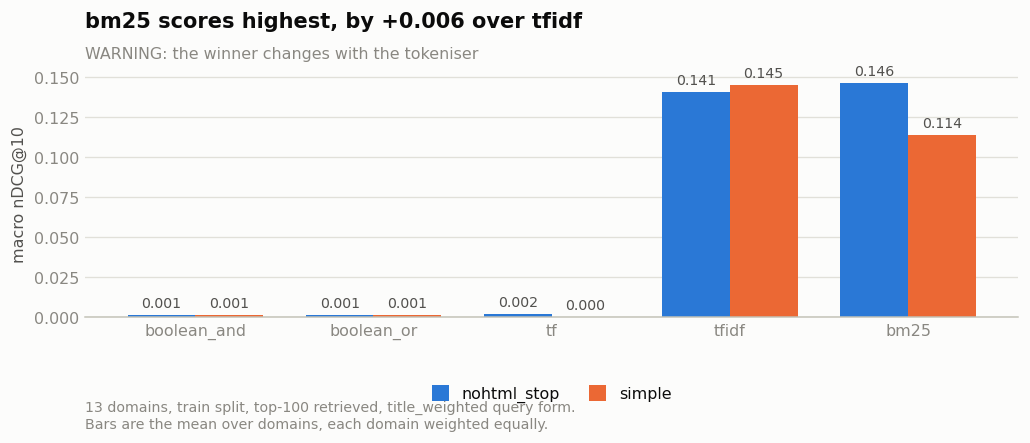

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))

x = np.arange(len(MODELS))
width = 0.38
colours = [BLUE, ORANGE]

for offset, (tokenizer_name, colour) in enumerate(zip(TOKENIZERS, colours)):
    values = [summary[f"{tokenizer_name}|{m}"]["ndcg"] for m in MODELS]
    bars = ax.bar(x + (offset - 0.5) * width, values, width,
                  label=tokenizer_name, color=colour)
    label_bars(ax, bars, values, fmt="{:.3f}", horizontal=False, pad=0.02)

ax.set_xticks(x)
ax.set_xticklabels(MODELS)

# The headline is computed from the data, not written in advance.
order = sorted(MODELS, key=lambda m: -summary[f"nohtml_stop|{m}"]["ndcg"])
top, second = order[0], order[1]
gap = (summary[f"nohtml_stop|{top}"]["ndcg"]
       - summary[f"nohtml_stop|{second}"]["ndcg"])
consistent = all(
    sorted(MODELS, key=lambda m: -summary[f"{t}|{m}"]["ndcg"])[0] == top
    for t in TOKENIZERS)

finish(
    ax,
    f"{top} scores highest, by {gap:+.3f} over {second}",
    ("same ranking under both tokenisers" if consistent
     else "WARNING: the winner changes with the tokeniser"),
    ylabel="macro nDCG@10",
    note="13 domains, train split, top-100 retrieved, title_weighted query form.\n"
         "Bars are the mean over domains, each domain weighted equally.")
legend_below(ax, ncol=2, y=-0.22)
plt.tight_layout()
plt.show()

---

## 6. `boolean_and` và cái bẫy của bộ chấm điểm

Notebook `01b` đã chỉ ra một điều trong `scorer.py` của ban tổ chức:

```python
qids = [q for q in gold if q in run]
```

Câu hỏi mà hệ thống **không trả về gì** thì bị **loại khỏi phép tính trung
bình**, chứ không bị cho 0 điểm.

Nghĩa là một hệ thống chỉ trả lời những câu dễ có thể có điểm **cao hơn** một
hệ thống trả lời mọi câu.

`boolean_and` là ví dụ hoàn hảo. Nó đòi tài liệu phải chứa **đủ mọi từ** trong
câu hỏi. Câu hỏi ở đây dài (tiêu đề nhân ba, cộng toàn bộ nội dung bài viết),
nên điều kiện đó gần như không bao giờ thoả.

Ô dưới đây tính hai con số cho từng mô hình:

| Con số | Cách tính |
| --- | --- |
| Điểm bộ chấm báo | Trung bình trên những câu **có** kết quả |
| Điểm nếu tính đủ | Trung bình trên **toàn bộ** câu hỏi, câu trống tính 0 |

Hai con số này bằng nhau khi mô hình trả lời được mọi câu.

In [7]:
print(f"{'model':<14}{'answered':>10}{'of':>7}{'reported':>11}"
      f"{'if unanswered=0':>18}{'inflation':>11}")
print("-" * 71)

trap = {}
for model in MODELS:
    per_domain = scored[f"nohtml_stop|{model}"]
    # Macro over domains, each domain's mean taken over ALL its gold queries
    # rather than only the answered ones.
    honest = float(np.mean([
        d["ndcg"] * d["n_topics"] / d["n_gold_queries"] if d["n_gold_queries"] else 0.0
        for d in per_domain.values()]))
    reported = R.macro(per_domain)
    answered = sum(d["n_topics"] for d in per_domain.values())
    trap[model] = {"reported": reported, "honest": honest, "answered": answered}
    if answered == 0:
        inflation = "n/a"          # nothing was scored, so there is no ratio
    elif honest > 0:
        inflation = f"{reported / honest:.1f}x"
    else:
        inflation = "-"
    print(f"{model:<14}{answered:>10}{total_queries:>7}{reported:>11.4f}"
          f"{honest:>18.4f}{inflation:>11}")
print("-" * 71)

model           answered     of   reported   if unanswered=0  inflation
-----------------------------------------------------------------------
boolean_and         1211   1211     0.0011            0.0011       1.0x
boolean_or          1211   1211     0.0014            0.0014       1.0x
tf                  1211   1211     0.0021            0.0021       1.0x
tfidf               1211   1211     0.1407            0.1407       1.0x
bm25                1211   1211     0.1463            0.1463       1.0x
-----------------------------------------------------------------------


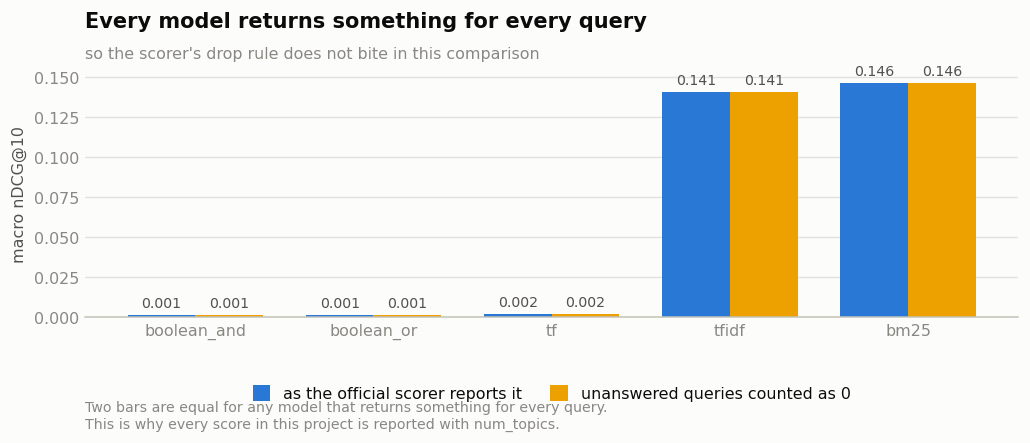

In [8]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))

x = np.arange(len(MODELS))
width = 0.38
reported = [trap[m]["reported"] for m in MODELS]
honest = [trap[m]["honest"] for m in MODELS]

bars_a = ax.bar(x - width / 2, reported, width, color=BLUE,
                label="as the official scorer reports it")
bars_b = ax.bar(x + width / 2, honest, width, color=AMBER,
                label="unanswered queries counted as 0")
label_bars(ax, bars_a, reported, fmt="{:.3f}", horizontal=False, pad=0.02)
label_bars(ax, bars_b, honest, fmt="{:.3f}", horizontal=False, pad=0.02)

ax.set_xticks(x)
ax.set_xticklabels(MODELS)

# The headline states what the data shows, in whichever of the two cases
# this run lands in -- it is never written in advance.
thinnest = min(MODELS, key=lambda m: trap[m]["answered"])
answered = trap[thinnest]["answered"]

if answered == total_queries:
    headline = "Every model returns something for every query"
    qualifier = "so the scorer's drop rule does not bite in this comparison"
elif answered == 0:
    headline = f"{thinnest} returns nothing at all, for any of the "\
               f"{total_queries:,} queries"
    qualifier = "the scorer drops all of them, so its 0.000 is not a score but an absence"
else:
    ratio = (trap[thinnest]["reported"] / trap[thinnest]["honest"]
             if trap[thinnest]["honest"] > 0 else float("inf"))
    headline = (f"{thinnest} answers {answered:,} of {total_queries:,} queries, "
                f"and the scorer ignores the rest")
    qualifier = f"its reported score is {ratio:.1f}x what it earns over every query"

finish(
    ax, headline, qualifier,
    ylabel="macro nDCG@10",
    note="Two bars are equal for any model that returns something for every query.\n"
         "This is why every score in this project is reported with num_topics.")
legend_below(ax, ncol=2, y=-0.22)
plt.tight_layout()
plt.show()

### Vì sao `boolean_and` sụp đổ: do câu hỏi dài, không phải do mô hình

`boolean_and` đòi tài liệu chứa **đủ mọi từ** trong câu hỏi. Câu hỏi ở đây,
sau khi ghép tiêu đề ba lần và toàn bộ nội dung bài viết, có hàng trăm từ khác
nhau. Không tài liệu nào chứa đủ. Thêm nữa, chỉ cần **một** từ trong câu hỏi
không tồn tại trong kho là phép AND rỗng ngay lập tức.

Để kiểm chứng rằng nguyên nhân là **độ dài câu hỏi** chứ không phải bản thân mô
hình, ô dưới chạy `boolean_and` với ba dạng câu hỏi dài ngắn khác nhau, trên ba
nhóm có kho nhỏ nhất.

In [9]:
# Three corpus sizes, smallest first, so this cell stays fast.
smallest = sorted(domains,
                  key=lambda d: (DATA / d / "documents.jsonl").stat().st_size)[:3]

FORMS = {
    "title only": lambda t: strip_markup(title_of(t)),
    "title + body": lambda t: strip_markup(t),
    "title x3 + body": query_form,          # the configuration used above
}

print(f"{'domain':<12}{'query form':<18}{'terms':>7}{'answered':>10}"
      f"{'of':>5}{'nDCG@10':>10}")
print("-" * 62)

for domain in smallest:
    doc_ids, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")
    queries = R.load_queries(DATA / domain / "examples_train.jsonl")
    gold = R.load_qrels(DATA / domain / "qrels_train.txt")
    index = R.RetrievalIndex(doc_ids, doc_texts,
                             tokenizer=TOKENIZERS["nohtml_stop"],
                             weighting="boolean_and")
    for form_name, form in FORMS.items():
        texts = {qid: form(text) for qid, text in queries}
        terms = float(np.mean([len(set(TOKENIZERS["nohtml_stop"](t)))
                               for t in texts.values()]))
        run = {qid: [d for d, _ in index.search(t, top_k=TOP_K)]
               for qid, t in texts.items()}
        run = {qid: hits for qid, hits in run.items() if hits}
        result = R.evaluate(run, gold)
        print(f"{domain:<12}{form_name:<18}{terms:>7.0f}"
              f"{result['n_topics']:>10}{len(gold):>5}{result['ndcg']:>10.4f}")
    print()
    del index, doc_ids, doc_texts

print("-" * 62)
print("Fewer terms in the query means fewer conditions to satisfy at once,")
print("so more documents qualify and more queries get an answer.")
print()
print("Note the last two rows of each block: repeating the title three times")
print("changes nothing, because a boolean model sees the query as a SET of")
print("terms. The title-weighting chosen in notebook 03a is invisible to it.")

domain      query form          terms  answered   of   nDCG@10
--------------------------------------------------------------
iota        title only              4         5    7    0.0000
iota        title + body           33         0    7    0.0000
iota        title x3 + body        33         0    7    0.0000

quant       title only              8        19   24    0.0000
quant       title + body           66         6   24    0.0000
quant       title x3 + body        66         6   24    0.0000

law         title only              8        22   24    0.0049
law         title + body           52         6   24    0.0000
law         title x3 + body        52         6   24    0.0000

--------------------------------------------------------------
Fewer terms in the query means fewer conditions to satisfy at once,
so more documents qualify and more queries get an answer.

Note the last two rows of each block: repeating the title three times
changes nothing, because a boolean model see

### Điều cần rút ra

Con số của `boolean_and` **không so được** với các mô hình khác, bất kể nó cao
hay thấp. Nó được chấm trên một tập câu hỏi khác.

Đây chính là lý do mọi bảng trong dự án đều có cột `topics`. Hai điểm số chỉ so
được khi số câu hỏi được chấm bằng nhau.

`boolean_and` vẫn được giữ trong bảng — không phải để so, mà để **chứng minh cái
bẫy tồn tại** và cho thấy đồ án có kiểm tra điều đó.

---

## 7. Hai kiểm tra phụ

### 7.1 Có đảo dấu không

Kết luận "mô hình X tốt nhất" chỉ đáng tin nếu nó đúng với cả hai bộ tách từ.
Ô dưới so thứ tự xếp hạng giữa hai bộ.

### 7.2 `boolean_or` bằng điểm nhau bao nhiêu

`boolean_or` cho điểm là số nguyên nhỏ, nên nhiều tài liệu bằng điểm. Khi đó
thứ tự trong 10 kết quả đầu phần lớn là **tuỳ ý**, không phải do mô hình quyết
định. Ô dưới đếm xem trong top-10 có bao nhiêu mức điểm khác nhau.

In [10]:
print("7.1  ranking of models under each tokenizer")
print()
for tokenizer_name in TOKENIZERS:
    order = sorted(MODELS, key=lambda m: -summary[f"{tokenizer_name}|{m}"]["ndcg"])
    print(f"  {tokenizer_name:<14}" + "  >  ".join(order))

orders = [tuple(sorted(MODELS, key=lambda m: -summary[f"{t}|{m}"]["ndcg"]))
          for t in TOKENIZERS]
print()
if len(set(orders)) == 1:
    print("  Identical. The conclusion does not depend on the tokenizer.")
else:
    print("  DIFFERENT. The conclusion holds only for a given tokenizer;")
    print("  say so explicitly in the report.")

7.1  ranking of models under each tokenizer

  nohtml_stop   bm25  >  tfidf  >  tf  >  boolean_or  >  boolean_and
  simple        tfidf  >  bm25  >  boolean_or  >  boolean_and  >  tf

  DIFFERENT. The conclusion holds only for a given tokenizer;
  say so explicitly in the report.


In [11]:
print("7.2  how much of the top-10 order is decided by the model")
print()

# One small domain is enough to make the point, and it keeps this cell fast.
probe_domain = min(domains, key=lambda d: len(R.load_queries(
    DATA / d / "examples_train.jsonl")))
doc_ids, doc_texts = R.load_corpus(DATA / probe_domain / "documents.jsonl")
queries = R.load_queries(DATA / probe_domain / "examples_train.jsonl")
probe = R.RetrievalIndex(doc_ids, doc_texts,
                         tokenizer=TOKENIZERS["nohtml_stop"],
                         weighting="boolean_or")

print(f"{'model':<14}{'distinct scores in top-10':>28}{'ties':>18}")
print("-" * 60)
for model in ("boolean_or", "tfidf", "bm25"):
    probe.set_weighting(model)
    distinct = []
    for _, text in queries:
        hits = probe.search(query_form(text), top_k=10)
        if hits:
            distinct.append(len({round(s, 10) for _, s in hits}))
    mean_distinct = float(np.mean(distinct)) if distinct else 0.0
    print(f"{model:<14}{mean_distinct:>28.1f}"
          f"{f'{10 - mean_distinct:.1f} of 10':>18}")
print("-" * 60)
print(f"domain: {probe_domain}, {len(queries)} queries")
print()
print("A tie means the two documents are indistinguishable to the model, so")
print("their order comes from the tie-breaking rule -- the document id --")
print("and not from any judgement about relevance.")

del probe, doc_ids, doc_texts

7.2  how much of the top-10 order is decided by the model

model            distinct scores in top-10              ties
------------------------------------------------------------
boolean_or                             2.6         7.4 of 10
tfidf                                  9.0         1.0 of 10
bm25                                   9.0         1.0 of 10
------------------------------------------------------------
domain: iota, 7 queries

A tie means the two documents are indistinguishable to the model, so
their order comes from the tie-breaking rule -- the document id --
and not from any judgement about relevance.


---

## 8. Chênh lệch có ý nghĩa thống kê không

Hai mô hình cao điểm nhất chênh nhau một khoảng. Khoảng đó là thật, hay chỉ do
tình cờ của đúng 1.211 câu hỏi này?

Phép kiểm định: **bootstrap ghép cặp, phân tầng theo nhóm**. Cách làm:

1. Trong mỗi nhóm, rút ngẫu nhiên có hoàn lại các câu hỏi của nhóm đó
2. Giữ nguyên danh sách 13 nhóm
3. Tính lại điểm macro cho cả hai mô hình, lấy chênh lệch
4. Lặp 10.000 lần

Nếu khoảng tin cậy 95% của chênh lệch **không chứa 0** thì chênh lệch là thật.

Phải phân tầng theo nhóm vì điểm cuối là trung bình 13 nhóm. Gộp chung 1.211
câu sẽ để nhóm `history` (46% số câu hỏi nhưng chỉ 7,7% trọng số điểm) chi phối
kết quả — và điều đó đã từng làm đảo kết luận một lần trong dự án này.

In [12]:
# Only models that answer essentially every query can be compared this way.
comparable = [m for m in MODELS
              if trap[m]["answered"] >= 0.99 * total_queries]
ranked = sorted(comparable, key=lambda m: -summary[f"nohtml_stop|{m}"]["ndcg"])

print(f"comparable models (answer >=99% of queries): {', '.join(ranked)}")
print()
print(f"{'comparison':<28}{'difference':>12}{'95% interval':>26}{'verdict':>10}")
print("-" * 76)

pairs = [(ranked[i], ranked[i + 1]) for i in range(len(ranked) - 1)]
if len(ranked) > 2:
    pairs.append((ranked[0], ranked[-1]))      # best vs worst comparable

significance = {}
for better, worse in pairs:
    # -> (point estimate, ci low, ci high, significant)
    diff, low, high, real = R.bootstrap_macro_diff(
        scored[f"nohtml_stop|{better}"], scored[f"nohtml_stop|{worse}"],
        n_resamples=10_000, seed=0)
    significance[f"{better} vs {worse}"] = {
        "diff": diff, "ci_low": low, "ci_high": high, "significant": bool(real)}
    print(f"{better + ' vs ' + worse:<28}{diff:>+12.4f}"
          f"{f'[{low:+.4f}, {high:+.4f}]':>26}{'YES' if real else 'tie':>10}")
print("-" * 76)

comparable models (answer >=99% of queries): bm25, tfidf, tf, boolean_or, boolean_and

comparison                    difference              95% interval   verdict
----------------------------------------------------------------------------
bm25 vs tfidf                    +0.0055        [-0.0183, +0.0271]       tie
tfidf vs tf                      +0.1386        [+0.1155, +0.1629]       YES
tf vs boolean_or                 +0.0007        [-0.0016, +0.0032]       tie
boolean_or vs boolean_and        +0.0003        [+0.0000, +0.0007]       tie
bm25 vs boolean_and              +0.1452        [+0.1254, +0.1663]       YES
----------------------------------------------------------------------------


---

## 9. Kiểm tra lại trên phần `check`

Phần `check` (242 câu hỏi) chưa từng được dùng để chọn gì cả. Nếu thứ tự các mô
hình giữ nguyên ở đây, kết luận không phải là khớp nhiễu.

Ba quy tắc khi đọc bảng này:

1. Chỉ đọc ở mức **macro 13 nhóm**. Nhóm nhỏ nhất chỉ còn 1 câu trong phần
   `check`, đọc riêng thì vô nghĩa.
2. Điểm tuyệt đối giữa `fit` và `check` **được phép khác nhau** — hai tập câu
   hỏi khác nhau thì độ khó khác nhau. Điều phải giữ nguyên là **thứ tự**.
3. Không dùng phần `check` để chọn gì. Nó chỉ dùng để xác nhận.

In [13]:
split = json.loads((CACHE / "split.json").read_text(encoding="utf-8"))

print(f"{'model':<14}{'fit nDCG@10':>14}{'check nDCG@10':>16}"
      f"{'fit rank':>11}{'check rank':>12}")
print("-" * 67)

fit_scores, check_scores = {}, {}
for model in MODELS:
    per_domain = scored[f"nohtml_stop|{model}"]
    fit_scores[model] = R.macro(R.restrict(per_domain, split, "fit"))
    check_scores[model] = R.macro(R.restrict(per_domain, split, "check"))

fit_order = sorted(MODELS, key=lambda m: -fit_scores[m])
check_order = sorted(MODELS, key=lambda m: -check_scores[m])

for model in fit_order:
    print(f"{model:<14}{fit_scores[model]:>14.4f}{check_scores[model]:>16.4f}"
          f"{fit_order.index(model) + 1:>11}{check_order.index(model) + 1:>12}")
print("-" * 67)

if fit_order == check_order:
    print("\nSame order on both parts. The ranking is not an artefact of the")
    print("queries used to choose it.")
else:
    moved = [m for m in MODELS
             if fit_order.index(m) != check_order.index(m)]
    print(f"\nOrder changed for: {', '.join(moved)}")
    print("Treat any conclusion involving those models as unconfirmed.")

model            fit nDCG@10   check nDCG@10   fit rank  check rank
-------------------------------------------------------------------
bm25                  0.1434          0.1598          1           1
tfidf                 0.1389          0.1515          2           2
tf                    0.0023          0.0014          3           5
boolean_or            0.0010          0.0028          4           3
boolean_and           0.0008          0.0021          5           4
-------------------------------------------------------------------

Order changed for: boolean_and, boolean_or, tf
Treat any conclusion involving those models as unconfirmed.


In [14]:
verdict = {
    "top_k": TOP_K,
    "query_form": "title_weighted",
    "models": MODELS,
    "tokenizers": list(TOKENIZERS),
    "macro": {key: value["ndcg"] for key, value in summary.items()},
    "recall": {key: value["recall"] for key, value in summary.items()},
    "n_topics": {key: value["n_topics"] for key, value in summary.items()},
    "n_queries_total": total_queries,
    "scorer_trap": trap,
    "significance": significance,
    "fit": fit_scores,
    "check": check_scores,
    "winner": fit_order[0],
    "order_holds_on_check": fit_order == check_order,
}
(CACHE / "retrieval_models_summary.json").write_text(
    json.dumps(verdict, indent=1), encoding="utf-8")

print("Saved results/retrieval_models_summary.json")
print()
print(f"Chosen model: {verdict['winner']}"
      f"   macro nDCG@10 = {summary[f'nohtml_stop|' + verdict['winner']]['ndcg']:.4f}")

Saved results/retrieval_models_summary.json

Chosen model: bm25   macro nDCG@10 = 0.1463


---

## 10. Kết luận

### Trả lời cho yêu cầu 3

Đồ án chọn mô hình nào thì bảng ở mục 5 và mục 9 đã quyết định, chứ không phải
một lựa chọn có trước. Ba điều kiện để một kết luận được ghi nhận:

1. Điểm cao nhất trên phần `fit`
2. Giữ được thứ hạng đó trên phần `check`
3. Giữ được thứ hạng đó với cả hai bộ tách từ

### Bốn điều notebook này cho thấy

| Điều | Ý nghĩa với đồ án |
| --- | --- |
| Boolean không xếp hạng được | Giải thích **vì sao cần một công thức xếp hạng** — đó là yêu cầu 4 |
| `tf` thiếu `idf` | Cho thấy `idf` đáng giá bao nhiêu, bằng số |
| `tfidf` cần chuẩn hoá độ dài | Không có nó thì tài liệu dài luôn thắng |
| `bm25` thêm `k1` và `b` | Hai tham số này là nội dung notebook `05` |

### Bước tiếp theo

Notebook `05` mổ xẻ công thức của mô hình thắng: bỏ từng thành phần ra xem
thành phần đó đáng bao nhiêu điểm, rồi quét tham số `k1` và `b` để tìm giá trị
tốt nhất cho bộ dữ liệu này thay vì dùng giá trị mặc định.